In [22]:
%pip install docling | tail -n 1
%pip install langchain-groq | tail -n 1
%pip install langchain-community | tail -n 1
%pip install ddgs | tail -n 1
%pip install langchain_deepseek | tail -n 1

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.


## Need to conver the resume to markdown
- `docling` to convert the resume to markdown

In [2]:
# need to input a resume (pdf)
# convert the resume to markdown
import os
from docling.document_converter import DocumentConverter

resume_path = "../data/resume.pdf"

def convert_to_markdown(doc_path):
    if not os.path.exists(doc_path):
        raise FileNotFoundError(f"Document not found at path: {doc_path}")
    converter = DocumentConverter()
    markdown = converter.convert(doc_path).document.export_to_markdown()
    return markdown

markdown_resume = convert_to_markdown(resume_path)
# print(markdown_resume)

/home/aneesh/machine learning projects/application development with LLMs/venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[INFO] 2026-04-14 19:15:20,226 [RapidOCR] base.py:22: Using engine_name: torch
[INFO] 2026-04-14 19:15:20,231 [RapidOCR] device_config.py:57: Using CPU device
[INFO] 2026-04-14 19:15:20,273 [RapidOCR] download_file.py:60: File exists and is valid: /home/aneesh/machine learning projects/application development with LLMs/venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-14 19:15:20,274 [RapidOCR] main.py:50: Using /home/aneesh/machine learning projects/application development with LLMs/venv/lib/python3.12/site-packages/rapidocr/models/ch_PP-OCRv4_det_mobile.pth
[INFO] 2026-04-14 19:15:20,508 [RapidOCR] base.py:22: Using engine_name: torch
[

## JD
- JD is provided as text file

In [3]:
jd_path = "../data/jd.txt"

def extract_jd(path):
    if not os.path.exists(path):
        raise FileNotFoundError(f"JD file not found at path: {path}")
    with open(path, "r") as f:
        jd = f.read()

    return jd

jd = extract_jd(jd_path)
# print(jd)

## LLMs
- load llm and test llm

In [4]:
from dotenv import load_dotenv

# Load environment variables from .env file
load_dotenv("../.env")
os.environ["GROQ_API_KEY"] = os.getenv("GROQ")

# load llms
from langchain_groq import ChatGroq

# model = "openai/gpt-oss-120b"
# model = "llama-3.3-70b-versatile"
model = "llama-3.1-8b-instant"
# model = "meta-llama/llama-4-scout-17b-16e-instruct"
# model = "deepseek-r1-distill-llama-70b"

llm = ChatGroq(
    model=model,
    temperature=0
)

# to test the llm
response = llm.invoke("What is the capital of France during the Nepolionic era?")
print(response)




content='During the Napoleonic era, the capital of France was Paris.' additional_kwargs={} response_metadata={'token_usage': {'completion_tokens': 15, 'prompt_tokens': 48, 'total_tokens': 63, 'completion_time': 0.021308168, 'completion_tokens_details': None, 'prompt_time': 0.003868169, 'prompt_tokens_details': None, 'queue_time': 0.047493159, 'total_time': 0.025176337}, 'model_name': 'llama-3.1-8b-instant', 'system_fingerprint': 'fp_d9492c3c54', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'} id='lc_run--019d8cfd-be90-7531-9839-9c37c7c1b0be-0' tool_calls=[] invalid_tool_calls=[] usage_metadata={'input_tokens': 48, 'output_tokens': 15, 'total_tokens': 63}


In [25]:
from langchain_deepseek import ChatDeepSeek

load_dotenv("../.env")

llm = ChatDeepSeek(
    model="deepseek-chat",
    temperature=0,
    max_tokens=None,
    timeout=None,
    max_retries=2,
    api_key=os.getenv("DEEPSEEK")
)

llm.invoke("what is agentic workflow?")

AIMessage(content='Excellent question. **Agentic workflow** is a modern approach to using AI, particularly Large Language Models (LLMs), where you break down a complex task into a sequence of smaller, manageable steps, often delegating each step to a specialized "agent" or a single agent acting in different roles.\n\nThink of it as moving from giving an AI a single, broad command ("Build me a website") to designing and orchestrating a **multi-stage process** where the AI plans, executes, reviews, and iterates—much like a human project manager with a team of specialists.\n\n### Core Analogy: The Chef vs. The Kitchen Workflow\n*   **Non-Agentic (Traditional Prompting):** "Make me a gourmet lasagna." You get one output, which might be a recipe, a description, or a mess if the task is too complex.\n*   **Agentic Workflow:** You set up a process:\n    1.  **Agent 1 (Recipe Researcher):** Finds and compares top lasagna recipes.\n    2.  **Agent 2 (Shopper):** Creates a grocery list based on 

## Define Agents
- 2 agents
    - resume_writer
        - write resume based on `provided reaume`, `job description`, and `corrections from ats`
    - ats
        - review the resume base on 
            - jd
            - produce
                - keyword not availabe in resume
                - redundent information

- agentic flow
    - Reflection agnet
    - 4 iterations

In [15]:
from langchain_core.prompts import ChatPromptTemplate, MessagesPlaceholder
from langchain_core.messages import HumanMessage

generation_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are Dr. Paul Saladino, "a technical resume editor with expertise in optimizing 
        resumes for applicant tracking systems (ATS) and human recruiters. Your task is to 
        analyze the candidate's resume and the job description, and provide a revised version 
        of the resume that is tailored to the specific job requirements.

        you are provided with the following informations:
        1. {resume}
        2. {jd}

        Focus on: 
        - Highlighting the candidate's relevant experience and skills that align with the job description.
        - Restrict the changes only under the sections of job skills, experience, and perosnal skills.
        - Try to reword the candidate's experience to better fit the job requirements, while maintaining honesty and integrity.
        - Try to make the bullet points concise and impactful, using action verbs and quantifiable achievements where possible.
        - Provide the rationale for each change you suggest, explaining how it better aligns the candidate's resume with 
        the job description and increases the chances of passing through ATS and catching the attention of human recruiters inside the 
        brackets [] after each change.
        - Try to avoid dupliating the content in the resume, instead try to reword the existing content to better fit the job description. 
        and try to remove the alerady existing content if it does not fit the job description.
        - Use tools to research and gather information on the keywords and technologies
        if you are not sure about the relevance of a particular skill or experience to the job description, you can use the DuckDuckGoSearchResults 
        tool to search for the skill or experience along with the job title and see if it is commonly associated with that type of role.
        """
    ),
    MessagesPlaceholder(variable_name="messages"),
    (
        "system", 
        """
        - please keep all the headings and sections in the resume intact, only change the content under each section "
        to better fit the job description. Do not add or remove any sections or headings.
        - please don't alter the order of headings and sections in the resume, only change 
        the content under each section 
        """
    ),
])

In [6]:
# first_responder_prompt = generation_prompt.partial(
#     resume=markdown_resume,
#     jd=jd
# )
# temp_chain = first_responder_prompt| llm
# question = "Please give me bullet and poinsts under different headers to change in the existing resume."
# response = temp_chain.invoke({"messages": [HumanMessage(content=question)]})
# print(response.content)

## Reviewer

In [19]:
review_prompt = ChatPromptTemplate.from_messages([
    (
        "system",
        """You are Dr. Kerb Muller, "an HR expert specilized in evaluating technical resumes
        and judging the fit of a candidate for a technical position.

        you are provided with the following informations:
        1. {resume}
        2. {jd}

        Focus on: 
        - Evaluating the candidate's technical skills and experience against the job 
        requirements.
        - Highlight the missing skills and expertise the candidate should add to the resume 
        to better fit the job description.
        - Provide suggestions on how the candidate can better present their experience and 
        skills to align with the job description.
        - provide the suggestions in 500 words or less.
        """
    ),
    MessagesPlaceholder(variable_name="messages"),
])

# review_prompt_update = generation_prompt.partial(
#     resume=markdown_resume,
#     jd=jd
# )
# review_chain = review_prompt_update| llm
# question = """evaluate the resume agains the job description and give me suggestions on " \
# how to better fit the resume to the job description. please give your suggestion weather to 
# call the candidate for an interview or not based on the resume and the job description."""
# response = temp_chain.invoke({"messages": [HumanMessage(content=question)]})
# print(response.content)

In [26]:
from typing import Annotated, TypedDict
from langgraph.graph import StateGraph, START, END
from langgraph.graph.message import add_messages
from langchain_core.messages import BaseMessage, ToolMessage
from langchain_community.tools import DuckDuckGoSearchResults
from time import sleep

NO_ITERATION = 2

# define tools
tool_search = DuckDuckGoSearchResults()

tool_list = [tool_search]
tool_mapping = {tool.name: tool for tool in tool_list}

# schema to store Message History
class AgentState(TypedDict):
    # This keeps the conversation/critique histiroy
    messages: Annotated[list[BaseMessage], add_messages]
    # keeps the resume and jd
    resume: str
    jd: str
    iterations: int

# nodes
def generator_node(state: AgentState):
    # this node will generate the revised resume based on the initial resume and jd
    # it will also provide the rationale for each change suggested in the revised resume
    # and also provide suggestions on how to better fit the resume to the job description
    # it will also provide suggestions on whether to call the candidate for an interview or not based on the resume and the job description.
    chain = generation_prompt.partial(
        resume=state["resume"],
        jd=state["jd"]
    ) | llm
    sleep(10) # to show the progersss of the iterations

    response = chain.invoke({"messages": state["messages"]})
    return {
        "messages": [response],
        "resume": response.content    
    }

def route_after_generation(state: AgentState):
    # if there is a tool call it will route back to the tool_call node
    last_state = state["messages"][-1]
    if last_state.tool_calls:
        return "tool_call"
    return "reviewer"

def tool_call_node(state: AgentState):
    # this node will handle the tool call and update the state accordingly
    last_state = state["messages"][-1]

    print("tool_call")

    tool_messages = []
    for tool_call in last_state.tool_calls:

        name = tool_call.get("name")
        args = tool_call.get("args")

        if name in tool_mapping:
            tool_response = tool_mapping["name"](**args)
            tool_messages.append(
                ToolMessage(
                    content = str(tool_response),
                    id = tool_call.get("id")
                )
            )

    return {
        "messages": tool_messages #the tool_messages is a list
    }


def review_node(state: AgentState):
    # this node will review the revised resume and provide feedback on how to further improve it
    chain = review_prompt.partial(
        resume=state["resume"],
        jd=state["jd"]
    ) | llm

    # to show the progersss of the iterations
    iteration = state["iterations"] + 1
    print(f"iteration: {iteration}")
    sleep(10)

    # to limit the tookens in review, we will only pass the last 2 messages in the conversation history to the review node, which is the revised resume and the feedback from the generator node. this will help to reduce the token usage in the review node and also help to focus on the most recent changes suggested by the generator node.
    response = chain.invoke({"messages": state["messages"][:-2]})
    return {
        "messages": [response],
        "iterations": iteration
    }

def should_continue(state: AgentState):
    # this node will check if the stopping criterion is met or not
    # for example, we can stop after 3 iterations of generation and review
    if state["iterations"] >= NO_ITERATION:
        return END
    return "reviewer" # points to the node name


# generate workflow
workflow = StateGraph(AgentState)

# add nodes
workflow.add_node("generator", generator_node)
workflow.add_node("reviewer", review_node)
workflow.add_node("tool_call", tool_call_node)


# add edges
workflow.add_edge(START, "generator")
workflow.add_edge("reviewer", "generator")
workflow.add_edge("tool_call", "generator")

# conditional edge
workflow.add_conditional_edges(
    "generator", 
    should_continue,
    # to generate the conditional edge in the graph
    {
        "reviewer": "reviewer",
        END: END
    }
)

workflow.add_conditional_edges(
    "generator",
    route_after_generation,
    {
        "tool_call": "tool_call",
        "reviewer": "reviewer"
    }
)

# compile workflow
compiled_workflow = workflow.compile()

In [ ]:
from pprint import pprint

# need to provide an initial state to initialize the variables in the state graph
initial_state = {
    "messages": [HumanMessage(content="""
    Please update the resume as per the job description provided.
    """)],
    "resume": markdown_resume,
    "jd": jd,
    "iterations": 0
}

result = compiled_workflow.invoke(initial_state)
# print(result)

pprint(result["resume"])

iteration: 1
iteration: 2
iteration: 3


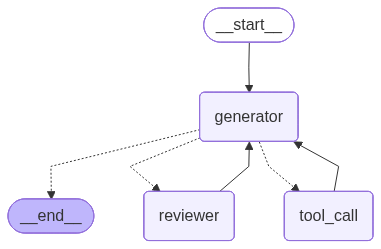

In [17]:
from IPython.display import Image, display

display(Image(compiled_workflow.get_graph().draw_mermaid_png()))